In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
### PARAMETERS ### 
start_year = 2012   # Change to 2012
end_year = 2025

tgt_year = 2020 # Target year for comparison 
before = False # Whether to compare the tgt_year to the year before (yr<tgt_year) or all other years (yr!=tgt_year).

In [3]:
### IMPORT DATAFRAMES (extractions from POIs) ### 
df_path = ('/home/jovyan/work/AVOCA/GEM/Development/Data/MODMYD_POI/') #
names = ['TerraD', 
         'TerraN', 
         'AquaD', 
         'AquaN', 
         'VIIRS_Day', 
         #'VIIRS_Night'
        ]

for sname in names:
    file_path = os.path.join(df_path, f'GEMLST_{sname}_LST_POI_reduced.csv')
    # if path exists, load the dataset into a dataframe and assign it to a global variable named after the sensor
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['year'] = pd.to_datetime(df['date']).dt.year
        globals()[f'{sname}_df'] = df
        print(f'Loaded {sname} dataset with {len(df)} observations')
    else:
        print(f'File not found: {file_path}')

mappings = {
    'TerraD_df': {'MOD_LST_Day':'lst', 'MOD_QA_Day':'qa'},
    'TerraN_df': {'MOD_LST_Night':'lst', 'MOD_QA_Night':'qa'},
    'AquaD_df': {'MYD_LST_Day':'lst', 'MYD_QA_Day':'qa'},
    'AquaN_df': {'MYD_LST_Night':'lst', 'MYD_QA_Night':'qa'},
    'VIIRS_Day_df': {'VIIRS_LST_1KM_C':'lst', 'VIIRS_QC':'qa'},
}

for df, mapping in mappings.items():
    globals()[df].rename(columns=mapping, inplace=True)

Loaded TerraD dataset with 26957637 observations
Loaded TerraN dataset with 9611127 observations
Loaded AquaD dataset with 25207622 observations
Loaded AquaN dataset with 8877112 observations
Loaded VIIRS_Day dataset with 13578687 observations


In [4]:
# DATA PREPARATION FUNCTIONS

# Group by poi and identify pois that have observations in every year
def filter_consistent_pois(df):
    '''Identify POIs with observations in every year'''
    poi_nyears = df.groupby('object_id')['year'].nunique()
    consistent_pois = poi_nyears[poi_nyears == (end_year - start_year + 1)].index
    consistent_df = df[df['object_id'].isin(consistent_pois)]
    return consistent_df

def prepare_data(df):
    '''Prepare data for analysis: filter years, calculate differences, select columns'''
    df = df.copy()

    # Filter years
    df = df[(df['year'] >= start_year) & (df['year'] <= end_year)]

    # Filter consistent POIs 
    df = filter_consistent_pois(df)
    return df
    
def calc_diff(df):
    # Calculate differences in LST and overfly time
    df['diff_lst'] = df['lst_x'] - df['lst_y']
    df['diff_time'] = df['time_x'] - df['time_y']
    return df

In [5]:
### CREATE PAIRED DATASETS FOR COMPARISON ###
Terra_Aqua_D = pd.merge(TerraD_df, AquaD_df, on=['object_id', 'date', 'class', 'year'])
Terra_Aqua_D = prepare_data(Terra_Aqua_D)
Terra_Aqua_D = calc_diff(Terra_Aqua_D)

# Terra_Aqua_N = pd.merge(TerraN_df, AquaN_df, on=['object_id', 'date', 'class', 'year'])
# Terra_Aqua_N = prepare_data(Terra_Aqua_N)

Terra_VIIRS_D = pd.merge(TerraD_df, VIIRS_Day_df, on=['object_id', 'date', 'class', 'year'])
Terra_VIIRS_D = prepare_data(Terra_VIIRS_D)
Terra_VIIRS_D = calc_diff(Terra_VIIRS_D)

Aqua_VIIRS_D = pd.merge(AquaD_df, VIIRS_Day_df, on=['object_id', 'date', 'class', 'year'])
Aqua_VIIRS_D = prepare_data(Aqua_VIIRS_D)
Aqua_VIIRS_D = calc_diff(Aqua_VIIRS_D)

# TerraN_VIIRSD = pd.merge(TerraN_df, VIIRS_Day_df, on=['object_id', 'date', 'class', 'year'])
# TerraN_VIIRSD = prepare_data(TerraN_VIIRSD)

# AquaN_VIIRSD = pd.merge(AquaN_df, VIIRS_Day_df, on=['object_id', 'date', 'class', 'year'])
# AquaN_VIIRSD = prepare_data(AquaN_VIIRSD)

# Terra_VIIRS_N = pd.merge(TerraN_df, VIIRS_Night_df, on=['object_id', 'date', 'class', 'year'])
# Terra_VIIRS_N = prepare_data(Terra_VIIRS_N)

# Aqua_VIIRS_N = pd.merge(AquaN_df, VIIRS_Night_df, on=['object_id', 'date', 'class', 'year'])
# Aqua_VIIRS_N = prepare_data(Aqua_VIIRS_N)

sensor_dict = {
    'TerraAqua_Day': Terra_Aqua_D,
    #'TerraAqua_Night': Terra_Aqua_N,

    'TerraVIIRS_Day': Terra_VIIRS_D,
    'AquaVIIRS_Day': Aqua_VIIRS_D,

    #'TerraNight_VIIRSDay': TerraN_VIIRSD,
    #'AquaNight_VIIRSDay': AquaN_VIIRSD

    # 'TerraVIIRS_Night': Terra_VIIRS_N,
    # 'AquaVIIRS_Night': Aqua_VIIRS_N
}

In [15]:
### Calculate median LST error for each year compared to baseline period

od_results = {}

def od_calc_median_error(df):
    '''Calculate cross-sensor median error for each year compared to a baseline period'''

    # Calculate cross-sensor baseline median lst and time differences (baseline = years before tgt_year)
    med_diff_lst_baseline = df[df['year']<tgt_year]['diff_lst'].median()

    # Aggregate statistics per year
    od_yr = df.groupby('year').agg(
            n_obs=('diff_lst', 'count'),
            med_diff_lst_yr =('diff_lst', 'median'),
            # med_diff_time=('diff_time', 'median'),
            avg_diff = ('diff_lst', 'mean'),
            std_dev=('diff_lst', 'std')
        ).reset_index()

    od_yr['med_diff_lst_bsl'] = med_diff_lst_baseline
    od_yr['delta_med_diff_lst'] = od_yr['med_diff_lst_yr'] - med_diff_lst_baseline

    return od_yr

for name, df in sensor_dict.items():
    od_yr = od_calc_median_error(df)
    od_yr['delta_med_diff_lst'] = od_yr['delta_med_diff_lst'].round(2)
    print(f'\n{name}:')
    print(od_yr)
    od_results[name] = od_yr
    # globals()[f'od_results_{name}'] = od_yr
    od_yr.to_csv(f'od_yr_{name}.csv', index=False)




TerraAqua_Day:
    year   n_obs  med_diff_lst_yr  avg_diff   std_dev  med_diff_lst_bsl  \
0   2012  928145             0.20  0.372509  2.238930              0.22   
1   2013  954279             0.22  0.383741  2.323732              0.22   
2   2014  918798             0.20  0.385500  2.312422              0.22   
3   2015  922446             0.26  0.402356  2.218842              0.22   
4   2016  925795             0.20  0.329537  2.296867              0.22   
5   2017  939538             0.22  0.366245  2.294940              0.22   
6   2018  901850             0.26  0.410145  2.331066              0.22   
7   2019  981284             0.22  0.407390  2.252181              0.22   
8   2020  851872             0.24  0.397763  2.323457              0.22   
9   2021  921878             0.18  0.361328  2.265576              0.22   
10  2022  785052             0.18  0.364607  2.283405              0.22   
11  2023  908397             0.16  0.301451  2.244401              0.22   
12  2024 

In [17]:
### Calculate median LST error for each year compared to baseline period
### Baseline depends on the parameters start and end year ### 

od_results_dt = {}
datasets = {'TerraD': TerraD_df, 'AquaD': AquaD_df, 'VIIRSD': VIIRS_Day_df}

def od_calc_median_dt(df):

    # Prepare dataset
    df = prepare_data(df)

    # Establish baseline acquisition time
    baseline_median_time = df[df['year']<tgt_year]['time'].median().round(2)
    
    # Aggregate statistics per year
    od_yr = df.groupby('year').agg(
            n_obs=('time', 'count'),
            med_time_yr=('time', 'median'),
            # med_diff_time=('diff_time', 'median'),
            avg_time = ('time', 'mean'),
            std_dev=('time', 'std')
        ).reset_index()

    od_yr['med_diff_time_bsl'] = baseline_median_time
    od_yr['delta_med_diff_time'] = od_yr['med_time_yr'] - baseline_median_time

    return od_yr, baseline_median_time

for name, df in datasets.items():
    od_yr_dt, baseline_median_time = od_calc_median_dt(df)
    od_yr_dt['delta_med_diff_time'] = od_yr_dt['delta_med_diff_time'].round(2)
    print(f'\n{name}, Baseline Median Time: {baseline_median_time}')
    print(od_yr_dt)
    od_results_dt[name] = od_yr_dt
    # globals()[f'od_results_{name}'] = od_yr
    od_yr_dt.to_csv(f'od_yr_time_{name}.csv', index=False) 


TerraD, Baseline Median Time: 12.7
    year    n_obs  med_time_yr   avg_time   std_dev  med_diff_time_bsl  \
0   2012  1147569         12.7  13.020370  1.529743               12.7   
1   2013  1188015         12.7  13.022042  1.512615               12.7   
2   2014  1141114         12.7  13.073400  1.560480               12.7   
3   2015  1157664         12.7  13.015997  1.524875               12.7   
4   2016  1131495         12.7  13.054325  1.536731               12.7   
5   2017  1161351         12.7  13.031538  1.513759               12.7   
6   2018  1138976         12.7  13.061971  1.526394               12.7   
7   2019  1188312         12.7  13.021282  1.518436               12.7   
8   2020  1110441         12.7  13.070169  1.548059               12.7   
9   2021  1171364         12.6  12.990949  1.560689               12.7   
10  2022  1043849         12.5  12.869711  1.620818               12.7   
11  2023  1142316         12.2  12.637548  1.671245               12.7   
12

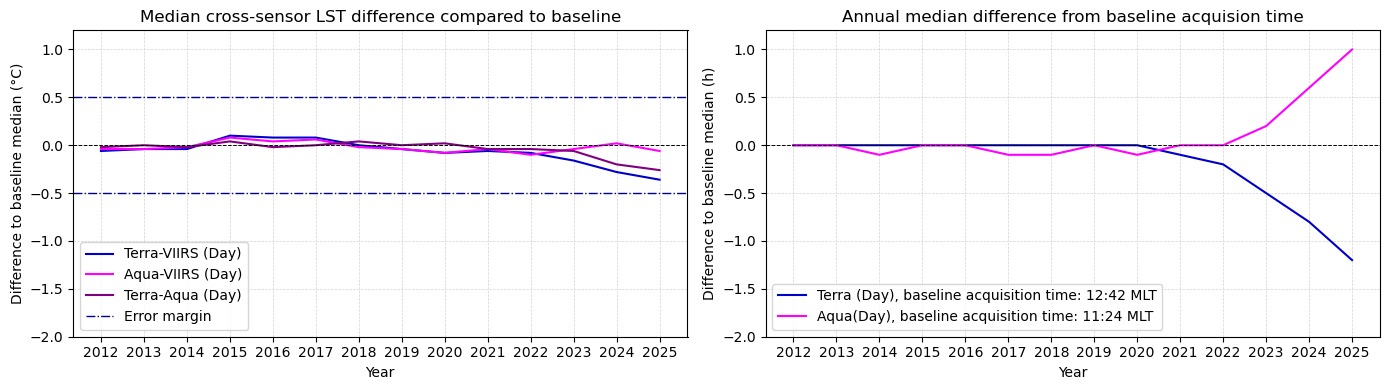

In [ ]:
# LST delta
fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(x='year', y='delta_med_diff_lst', data=od_results['TerraVIIRS_Day'], color='mediumblue', label='Terra-VIIRS (Day)', ax=ax)
sns.lineplot(x='year', y='delta_med_diff_lst', data=od_results['AquaVIIRS_Day'], color='magenta', label='Aqua-VIIRS (Day)', ax=ax)
sns.lineplot(x='year', y='delta_med_diff_lst', data=od_results['TerraAqua_Day'], color='purple', label='Terra-Aqua (Day)', ax=ax)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.7)
ax.axhline(y=-0.5, color='darkblue', linestyle='-.', linewidth=1, label='Error margin')
ax.axhline(y=0.5, color='darkblue', linestyle='-.', linewidth=1)
ax.set_title('Median cross-sensor LST difference compared to baseline')
ax.set_xlabel('Year')
ax.set_ylabel('Difference to baseline median (°C)')
ax.set_ylim(-2, 1.2)
ax.set_xticks(np.arange(start_year, end_year + 1, 1))
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig('od_graph_lst_delta.png', format='PNG', dpi=300, bbox_inches='tight')
fig.savefig('od_graph_lst_delta.pdf', format='PDF', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# Time delta
fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(x='year', y='delta_med_diff_time', data=od_results_dt['TerraD'], color='mediumblue', label='Terra (Day), baseline acquisition time: 12:42 MLT', ax=ax)
sns.lineplot(x='year', y='delta_med_diff_time', data=od_results_dt['AquaD'], color='magenta', label='Aqua (Day), baseline acquisition time: 11:24 MLT', ax=ax)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.7)
ax.set_title('Annual median difference from baseline acquisition time')
ax.set_xlabel('Year')
ax.set_ylabel('Difference to baseline median (h)')
ax.set_ylim(-2, 1.2)
ax.set_xticks(np.arange(start_year, end_year + 1, 1))
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig('od_graph_time_delta.png', format='PNG', dpi=300, bbox_inches='tight')
fig.savefig('od_graph_time_delta.pdf', format='PDF', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

# Left: LST delta
sns.lineplot(x='year', y='delta_med_diff_lst', data=od_results['TerraVIIRS_Day'], color='mediumblue', label='Terra-VIIRS (Day)', ax=ax1)
sns.lineplot(x='year', y='delta_med_diff_lst', data=od_results['AquaVIIRS_Day'], color='magenta', label='Aqua-VIIRS (Day)', ax=ax1)
sns.lineplot(x='year', y='delta_med_diff_lst', data=od_results['TerraAqua_Day'], color='purple',label='Terra-Aqua (Day)', ax=ax1)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.7)
ax1.axhline(y=-0.5, color='darkblue', linestyle='-.', linewidth=1, label='Error margin')
ax1.axhline(y=0.5, color='darkblue', linestyle='-.', linewidth=1)
ax1.set_title('Median cross-sensor LST difference compared to baseline')
ax1.set_xlabel('Year')
ax1.set_ylabel('Difference to baseline median (°C)')
ax1.set_ylim(-2, 1.2)
ax1.set_xticks(np.arange(start_year, end_year + 1, 1))
ax1.grid(color='lightgray', linestyle='--', linewidth=0.5)
ax1.legend(loc='lower left')


# Right: time delta
sns.lineplot(x='year', y='delta_med_diff_time', data=od_results_dt['TerraD'], color='mediumblue',label='Terra (Day), baseline acquisition time: 12:42 MLT', ax=ax2)
sns.lineplot(x='year', y='delta_med_diff_time', data=od_results_dt['AquaD'], color='magenta', label='Aqua(Day), baseline acquisition time: 11:24 MLT', ax=ax2)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.7)
ax2.set_title('Annual median difference from baseline acquision time')
ax2.set_xlabel('Year')
ax2.set_ylabel('Difference to baseline median (h)')
ax2.set_ylim(-2, 1.2)
ax2.set_xticks(np.arange(start_year, end_year + 1, 1))
ax2.grid(color='lightgray', linestyle='--', linewidth=0.5)
ax2.legend(loc='lower left')


plt.tight_layout()
plt.savefig('od_graph_lst_dt.png', format='PNG', dpi=300, bbox_inches='tight')

# Export figure as vector pdf
plt.savefig('od_graph_lst_dt.pdf', format='PDF', dpi=300, bbox_inches='tight')

plt.show()


24.0


In [23]:
# OTHER ANALYSIS FUNCTIONS

def visualize(df):
    '''Visualize differences over time using boxplots'''
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='year', y='diff_lst', data=df, showfliers=False)
    plt.title('Cross-sensor difference in LST over time')
    plt.xlabel('Year')
    plt.ylabel('LST Difference (°C)')
    plt.show()

def summarize(df): 
    '''Calculate summary statistics for each year'''
    df = prepare_data(df)
    summary = df.groupby('year').agg(
        n_obs=('diff_lst', 'count'),
        avg_diff_lst=('diff_lst', 'mean'),
        med_diff_lst=('diff_lst', 'median'),
        std_diff_lst=('diff_lst', 'std'),
        avg_diff_time=('diff_time', 'mean'),
        med_diff_time=('diff_time', 'median'),
        std_diff_time=('diff_time', 'std')
    ).reset_index()
    return summary

In [16]:
prepared_terra = prepare_data(Terra_VIIRS_D)
prepared_aqua = prepare_data(Aqua_VIIRS_D)
# identify_consistent_pois(prepared)

In [14]:
summarize(prepared_terra)

,year,n_obs,avg_diff_lst,med_diff_lst,std_diff_lst,avg_diff_time,med_diff_time,std_diff_time
0,2019,761487,0.768951,0.26,3.551632,11.964146,11.68,1.483951
1,2020,686524,0.590604,0.16,3.677907,12.008761,11.74,1.506257
2,2021,761642,0.617435,0.18,3.566545,11.904462,11.59,1.517349
3,2022,657931,0.703839,0.16,3.604553,11.798795,11.48,1.566659
4,2023,757870,0.516904,0.08,3.468560,11.567377,11.21,1.623819
5,2024,712911,0.387782,-0.04,3.444718,11.308645,10.89,1.788449
6,2025,740133,0.341065,-0.12,3.451263,11.085829,10.52,2.064761


In [17]:
summarize(prepared_aqua)

,year,n_obs,avg_diff_lst,med_diff_lst,std_diff_lst,avg_diff_time,med_diff_time,std_diff_time
0,2019,754363,0.487383,0.06,3.095804,10.189101,10.51,1.419846
1,2020,653296,0.373330,-0.02,3.151203,10.118368,10.43,1.444988
2,2021,734973,0.379941,0.02,3.146091,10.181277,10.51,1.446086
3,2022,624778,0.385627,-0.04,3.165792,10.160357,10.49,1.475410
4,2023,731659,0.364090,0.02,3.131099,10.325521,10.71,1.573061
5,2024,700434,0.425334,0.08,3.239846,10.569498,11.05,1.771632
6,2025,701402,0.471885,0.00,3.332518,10.834999,11.51,2.117512


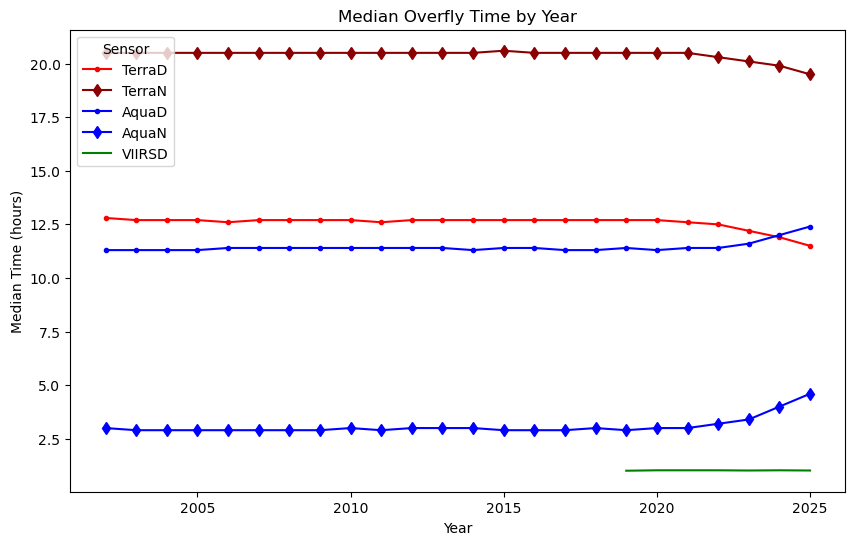

In [35]:
# Create plots of median overfly time by year for each sensor to visualize orbital drift
plt.figure(figsize=(10, 6))

TerraD_df.groupby('year')['time'].median().plot(color='red', label='TerraD', marker='.')
TerraN_df.groupby('year')['time'].median().plot(color='darkred', label='TerraN', marker='d')
AquaD_df.groupby('year')['time'].median().plot(color='blue', label='AquaD', marker='.')
AquaN_df.groupby('year')['time'].median().plot(color='blue', label='AquaN', marker='d')
VIIRS_Day_df.groupby('year')['time'].median().plot(color='green', label='VIIRSD')

plt.title('Median Overfly Time by Year')
plt.xlabel('Year')
plt.ylabel('Median Time (hours)')
plt.legend(title='Sensor', loc='upper left')
plt.show()

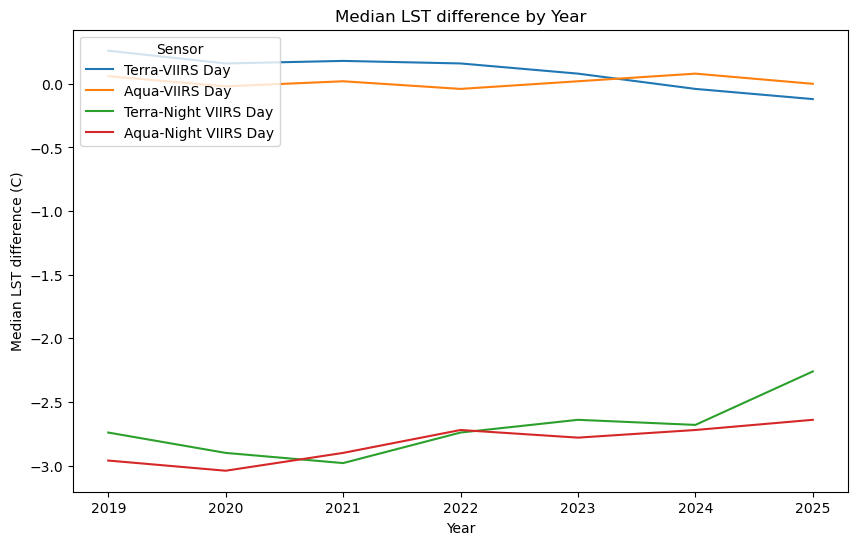

In [40]:
# Create plots of median LST-difference by year for each sensor to visualize orbital drift

plt.figure(figsize=(10, 6))
ax = plt.gca()

for name, df in sensor_dict.items():
    df_prepared = prepare_data(df)

    df_prepared.groupby('year')['diff_lst'].median().plot(ax=ax, label=name)

plt.title('Median LST difference by Year')
plt.xlabel('Year')
plt.ylabel('Median LST difference (C)')
plt.legend(title='Sensor', loc='upper left')

plt.show()


In [46]:
### Cross-sensor comparison: Terra vs Aqua 
# Compare 2020 to the years before

results_cross_sensor = {}

for name, df in sensor_dict.items():
    df_prepared = prepare_ttest(df, before=True, tgt_year=2020)
    result_lst, result_time = perform_ttest(df_prepared)
    # Add a row for each sensor comparison, with columns for t-statistic and p-value for both LST and time differences to the results dictionary
    results_cross_sensor.update({
        name: {
            't_statistic_lst': f'{result_lst.statistic:.2f}',
            'p_value_lst': f'{result_lst.pvalue:.3f}',
            't_statistic_time': f'{result_time.statistic:.2f}',
            'p_value_time': f'{result_time.pvalue:.3f}'
        }
    })

results_df = pd.DataFrame(results_cross_sensor)
print(results_df)



                 Terra-Aqua Night Terra-Aqua Day Terra-VIIRS Day  \
t_statistic_lst            -10.25          -0.23           22.71   
p_value_lst                 0.000          0.817           0.000   
t_statistic_time             3.14         -22.72           -0.17   
p_value_time                0.002          0.000           0.868   

                 Aqua-VIIRS Day Terra-Night VIIRS Day Aqua-Night VIIRS Day  
t_statistic_lst           15.35                  9.60                 2.39  
p_value_lst               0.000                 0.000                0.017  
t_statistic_time          13.46                 -2.44                -5.95  
p_value_time              0.000                 0.015                0.000  


In [7]:
# results_df.to_csv(os.path.join(df_path, 'cross_sensor_baseline_vs_2020.csv'), index=True)

In [47]:
### Perform the ttest for every year in yr_range against the baseline of all other years, separately for each sensor pair and for day and night. Print the results in a readable format, only if the p-value is below 0.05.

yr_range = range(start_year, end_year + 1)

for name, df in sensor_dict.items():
    print(f'\n{name} comparison:')
    for yr in yr_range:
        df_prepared = prepare_ttest(df, before=False, tgt_year=yr)
        ttest_lst, ttest_time = perform_ttest(df_prepared)
        if ttest_lst.pvalue < 0.05:
            print(f'\tLST: Year {yr} vs baseline: t-statistic = {ttest_lst.statistic:.2f}, p-value = {ttest_lst.pvalue:.4f}')
        if ttest_time.pvalue < 0.05:
            print(f'\tTime: Year {yr} vs baseline: t-statistic = {ttest_time.statistic:.2f}, p-value = {ttest_time.pvalue:.4f}')




Terra-Aqua Night comparison:
	LST: Year 2002 vs baseline: t-statistic = 11.88, p-value = 0.0000
	LST: Year 2003 vs baseline: t-statistic = 10.17, p-value = 0.0000
	Time: Year 2003 vs baseline: t-statistic = -13.70, p-value = 0.0000
	LST: Year 2004 vs baseline: t-statistic = 10.09, p-value = 0.0000
	Time: Year 2004 vs baseline: t-statistic = -5.10, p-value = 0.0000
	LST: Year 2005 vs baseline: t-statistic = -6.29, p-value = 0.0000
	Time: Year 2005 vs baseline: t-statistic = -11.40, p-value = 0.0000
	LST: Year 2006 vs baseline: t-statistic = 5.84, p-value = 0.0000
	Time: Year 2006 vs baseline: t-statistic = -4.93, p-value = 0.0000
	LST: Year 2007 vs baseline: t-statistic = -3.42, p-value = 0.0006
	Time: Year 2007 vs baseline: t-statistic = -9.18, p-value = 0.0000
	Time: Year 2009 vs baseline: t-statistic = 10.75, p-value = 0.0000
	LST: Year 2010 vs baseline: t-statistic = 7.08, p-value = 0.0000
	Time: Year 2010 vs baseline: t-statistic = 14.14, p-value = 0.0000
	LST: Year 2011 vs baseli

/tmp/ipykernel_460/3055539481.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_lst_results = stats.ttest_rel(df['diff_lst_baseline'], df['diff_lst_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:71: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_time_results = stats.ttest_rel(df['diff_time_baseline'], df['diff_time_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_lst_results = stats.ttest_rel(df['diff_lst_baseline'], df['diff_lst_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:71: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See

	LST: Year 2019 vs baseline: t-statistic = -22.71, p-value = 0.0000
	LST: Year 2020 vs baseline: t-statistic = 22.71, p-value = 0.0000

Aqua-VIIRS Day comparison:


/tmp/ipykernel_460/3055539481.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_lst_results = stats.ttest_rel(df['diff_lst_baseline'], df['diff_lst_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:71: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_time_results = stats.ttest_rel(df['diff_time_baseline'], df['diff_time_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_lst_results = stats.ttest_rel(df['diff_lst_baseline'], df['diff_lst_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:71: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See

	LST: Year 2019 vs baseline: t-statistic = -15.35, p-value = 0.0000
	Time: Year 2019 vs baseline: t-statistic = -13.46, p-value = 0.0000
	LST: Year 2020 vs baseline: t-statistic = 15.35, p-value = 0.0000
	Time: Year 2020 vs baseline: t-statistic = 13.46, p-value = 0.0000

Terra-Night VIIRS Day comparison:


/tmp/ipykernel_460/3055539481.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_lst_results = stats.ttest_rel(df['diff_lst_baseline'], df['diff_lst_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:71: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_time_results = stats.ttest_rel(df['diff_time_baseline'], df['diff_time_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_lst_results = stats.ttest_rel(df['diff_lst_baseline'], df['diff_lst_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:71: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See

	LST: Year 2019 vs baseline: t-statistic = -9.60, p-value = 0.0000
	Time: Year 2019 vs baseline: t-statistic = 2.44, p-value = 0.0145
	LST: Year 2020 vs baseline: t-statistic = 9.60, p-value = 0.0000
	Time: Year 2020 vs baseline: t-statistic = -2.44, p-value = 0.0145

Aqua-Night VIIRS Day comparison:


/tmp/ipykernel_460/3055539481.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_lst_results = stats.ttest_rel(df['diff_lst_baseline'], df['diff_lst_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:71: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_time_results = stats.ttest_rel(df['diff_time_baseline'], df['diff_time_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:70: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_lst_results = stats.ttest_rel(df['diff_lst_baseline'], df['diff_lst_target'], nan_policy='raise')
/tmp/ipykernel_460/3055539481.py:71: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See

	LST: Year 2019 vs baseline: t-statistic = -2.39, p-value = 0.0167
	Time: Year 2019 vs baseline: t-statistic = 5.95, p-value = 0.0000
	LST: Year 2020 vs baseline: t-statistic = 2.39, p-value = 0.0167
	Time: Year 2020 vs baseline: t-statistic = -5.95, p-value = 0.0000
